In [13]:
# %matplotlib widget
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from datetime import datetime, timedelta
import pandas as pd
import xarray as xr

In [14]:
file = "/datasets/FourCastNet/oct_2021_19_31_bath.nc"

In [15]:
dataset = xr.open_dataset(file, mode='r')
dataset

<xarray.Dataset> Size: 108MB
Dimensions:    (longitude: 720, latitude: 361, time: 52)
Coordinates:
  * longitude  (longitude) float32 3kB 0.0 0.5 1.0 1.5 ... 358.5 359.0 359.5
  * latitude   (latitude) float32 1kB 90.0 89.5 89.0 88.5 ... -89.0 -89.5 -90.0
  * time       (time) datetime64[ns] 416B 2021-10-19 ... 2021-10-31T18:00:00
Data variables:
    wmb        (time, latitude, longitude) float64 108MB ...
Attributes:
    Conventions:  CF-1.6
    history:      2024-08-30 13:32:57 GMT by grib_to_netcdf-2.28.1: /opt/ecmw...

In [16]:
fields = (dataset['wmb'][1]).compute()
fields.max(), fields.min()

(<xarray.DataArray 'wmb' ()> Size: 8B
 array(999.)
 Coordinates:
     time     datetime64[ns] 8B 2021-10-19T06:00:00,
 <xarray.DataArray 'wmb' ()> Size: 8B
 array(5.)
 Coordinates:
     time     datetime64[ns] 8B 2021-10-19T06:00:00)

<Figure size 640x480 with 0 Axes>

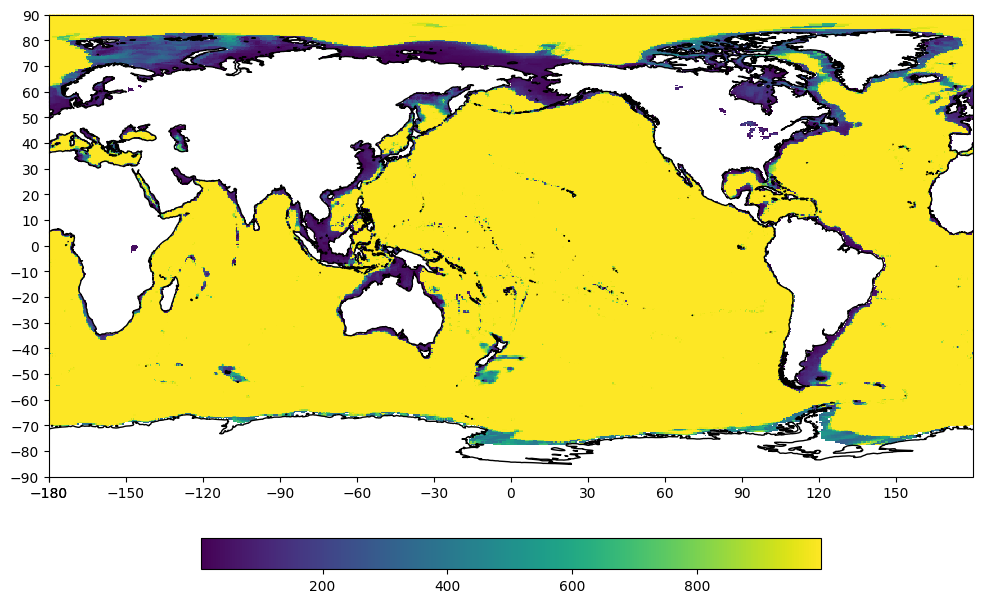

In [17]:
plt.clf()

fig = plt.figure(figsize=(16, 8))
ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=180))
ax.coastlines(resolution="50m")

ax.set_xticks(range(0, 361, 30), crs=ccrs.PlateCarree())
ax.set_yticks(range(-90, 91, 10), crs=ccrs.PlateCarree())
# ax.gridlines(draw_labels=False)

# 假设 lat 和 lon 是纬度和经度的数组
lat = np.linspace(90, -90, fields.shape[0])
lon = np.linspace(0, 360, fields.shape[1])
lon, lat = np.meshgrid(lon, lat)

c = ax.pcolormesh(lon, lat, fields, transform=ccrs.PlateCarree(), cmap='viridis')

# plt.xlim([x-180 for x in [98,140]])
# plt.ylim([0, 40])
plt.colorbar(c, ax=ax, orientation='horizontal', pad=0.1, shrink=0.5)
